# Conditional Generative Model for Images

**based on lab from MIT course ["Introduction to Flow Matching and Diffusion Models 2026"](https://diffusion.csail.mit.edu/2026/index.html)**

In [1]:
from models import VAE, DiffusionTransformerFlowModel
from trainers import VAETrainer, LatentCFGTrainer
from flow import GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta
from utils.latents import (
    visualize_latent_interpolation,
    estimate_latent_stats,
    convert_to_latent_dataset,
)
from utils.fid import fid_guidance_sweep

from typing import Optional
from matplotlib import pyplot as plt
from tqdm import tqdm

import torch
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset

# Part 1. Loading datasets

In [2]:
!nvidia-smi

Sun Jul  5 16:36:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.28.03              Driver Version: 560.28.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000               Off |   00000000:3B:00.0 Off |                  Off |
| 41%   24C    P8             13W /  140W |   13589MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
device = torch.device("cuda:2")

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)

cifar_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)


def cifar_reverse_transform(x):
    x = (x + 1.0) / 2.0
    return torch.clamp(x, 0.0, 1.0)

# Part 2: Training process

## 2.1: Training a VAE

In [4]:
vae = VAE(
    data_channels=3,
    hidden_channels=[8, 16, 16],
    beta=0.01,
).to(device)

In [5]:
train_dataloader = DataLoader(dataset=cifar, batch_size=64, shuffle=True)

trainer = VAETrainer(
    dataloader=train_dataloader,
    reverse_transform=cifar_reverse_transform,
)

In [6]:
# trainer.train(
#     model=vae,
#     num_epochs=100,
#     lr=1e-3,
#     warmup_steps=4 * len(train_dataloader),
#     ckpt_every=1,
#     run_name="vae_jul",
# )

In [7]:
trainer.load(model=vae, ckpt_name=f"epoch_{100}", ckpt_dir = "runs/vae_jul")
vae.to(device);

Loading model with size: 0.158 MiB


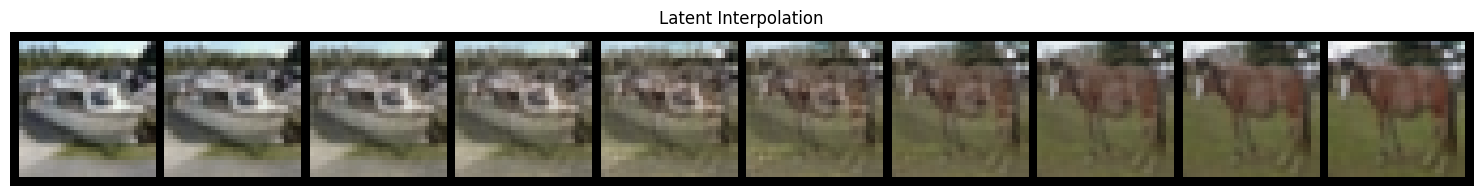

In [8]:
# Perform interpolation in the latent space
samples, _ = next(iter(DataLoader(cifar_test, batch_size=2, shuffle=True)))
samples = samples.to(device)

interpolated_samples = visualize_latent_interpolation(
    x1=samples[:1],
    x2=samples[1:2],
    vae=vae,
    n_steps=10,
    reverse_transform=cifar_reverse_transform,
)  # n_steps 3 h w

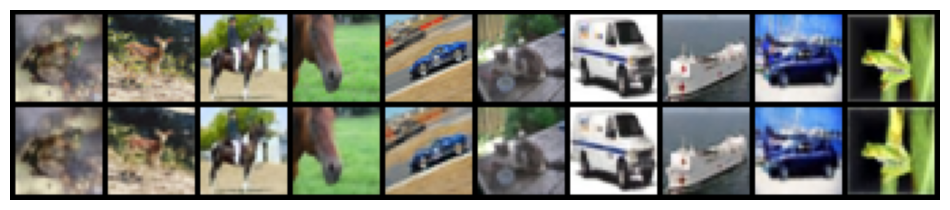

In [9]:
test_dataloader = DataLoader(dataset=cifar_test, batch_size=64, shuffle=True)
test_images, _ = next(iter(test_dataloader))
test_images = test_images[:10]
trainer.visualize_samples(images=test_images)

In [10]:
latent_mean, latent_std = estimate_latent_stats(vae, train_dataloader)

100%|██████████| 782/782 [00:20<00:00, 37.25it/s]


## 2.2 Training a Latent Diffusion Model

In [11]:
latent_cifar = convert_to_latent_dataset(vae, cifar)

Converting dataset to latents: 100%|██████████| 196/196 [00:17<00:00, 11.17it/s]


In [14]:
# Finally, let's train!

vae = vae.to(device)

# Initialize latent probability path
c = 16
img_size = 8

path = GaussianConditionalProbabilityPath(
    shape=[c, img_size, img_size],
    alpha=LinearAlpha(),
    beta=LinearBeta(),
)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size=img_size,
    patch_size=1,
    num_layers=16,
    c=c,
    dim=768,
    heads=8,
    final_dim=64,
    n_classes=11,
).to(device)

# Initialize trainer
trainer = LatentCFGTrainer(
    dataloader=DataLoader(dataset=latent_cifar, batch_size=256, shuffle=True),
    vae=vae,
    path=path,
    null_label=10,
    latent_stats=(latent_mean, latent_std),
    null_ratio=0.1,
    reverse_transform=cifar_reverse_transform,
)

In [15]:
trainer.train(
    model=dit,
    num_epochs=1000,
    lr=1e-4,
    ckpt_every=100,
    run_name="dit_jul",
    warmup_steps=10000,
    ema_decay=0.9999,
)

Initialized output directory at: runs/dit_jul
Training model with size: 658.771 MiB


Epoch 1/1000:   0%|          | 0/196000 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 192.00 MiB. GPU 2 has a total capacity of 15.63 GiB of which 166.50 MiB is free. Process 237606 has 158.00 MiB memory in use. Including non-PyTorch memory, this process has 15.30 GiB memory in use. Of the allocated memory 14.91 GiB is allocated by PyTorch, and 197.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
trainer.load(dit, ckpt_name=f"epoch_{1000}", ckpt_dir="runs/dit_jul")

# Part 3: Evaluation

In [ ]:
fid_guidance_sweep(trainer, "samples/dit_jul_epoch_1000/", num_timesteps=250)

In [ ]:
trainer.visualize_samples(
    save_path="results/gen_samples",
    samples_per_class=10,
    guidance_scales=(1.75, 2.0),
    use_tqdm=True,
    num_timesteps=250,
)